## Singular Value Decomposition
Any matrix $\bf A$ can be decomposed into model and data eigenvectors,
weighted by singular values:

$${\bf A} = \sum_i \sigma_i {\bf u}_i\cdot {\bf v}_i^T = {\bf U}{\bf \Sigma}{\bf V}^T$$

with the eigenvalues in $\Sigma=\text{diag}(\sigma_i)$, a set of orthogonal data eigenvectors ${\bf U}$ with ${\bf U}^{-1}={\bf U}^T$, and model eigenvectors ${\bf V}$ with ${\bf V}^{-1}={\bf V}^T$.


The eigenvectors associated with zero singular values ($\sigma_i=0$) span the null spaces of data and model. The number of (ordered descently) non-zero eigenvalues $p$ defines the rank of the matrix which can be abbreviated by

$${\bf A} = \sum_{i=1}^{p} \sigma_i {\bf u}\cdot {\bf v}^T = {\bf U}_p{\bf \Sigma}_p{\bf V}_p^T$$

where ${\bf B}_p$ holds the first $p$ columns of the matrix $\bf B$.

A matrix can be approximated by choosing the rank by hand.

The forward problem 
$${\bf G}{\bf m}={\bf d}$$
can be written in terms of SVD

$${\bf U}_p{\bf \Sigma}_p{\bf V}_p^T {\bf m}={\bf d}$$

can be rearranged by using ${\bf U}_p^T{\bf U}_p={\bf I}$ to

$${\bf \Sigma}_p{\bf V}_p^T {\bf m}={\bf U}^T_p{\bf d}$$

$${\bf V}_p^T {\bf m}={\bf \Sigma}^{-1}_p{\bf U}^T_p{\bf d}$$

$${\bf m}={\bf V}_p {\bf \Sigma}^{-1}_p{\bf U}^T_p{\bf d}$$


The generalized inverse ${\bf V}_p {\bf \Sigma}^{-1}_p{\bf U}^T_p$ is called the pseudo-inverse and equals 
$$({\bf G}^T{\bf G})^{-1}{\bf G}^T$$
i.e., the least-squares inverse for overdetermined problems.

By further truncating the number of nonzero singular values one can obtain a regularized solution for ill-posed (badly conditioned under-determined or mixed-determined) problems.

### Image compression by truncated SVD

We use the Images toolbox to load a greyscale image. `Pkg.add("Images")` might be necessary.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
img = plt.imread("rose8bit.png");
img.shape

(333, 500, 4)

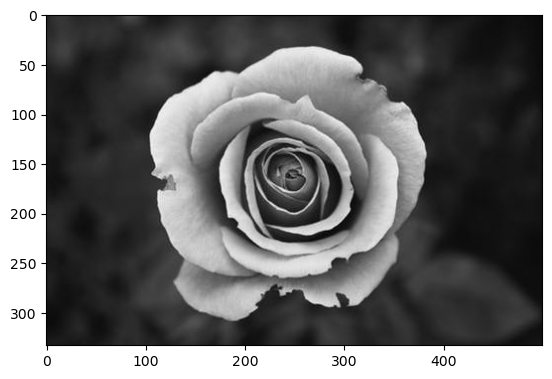

In [5]:
grey = img[:, :, 0]
plt.imshow(grey, cmap="gray");

In [6]:
U, s, V = np.linalg.svd(grey);
print(U.shape, s.shape, V.shape)

(333, 333) (333,) (500, 500)


In [18]:
np.linalg.matrix_rank(grey)

322

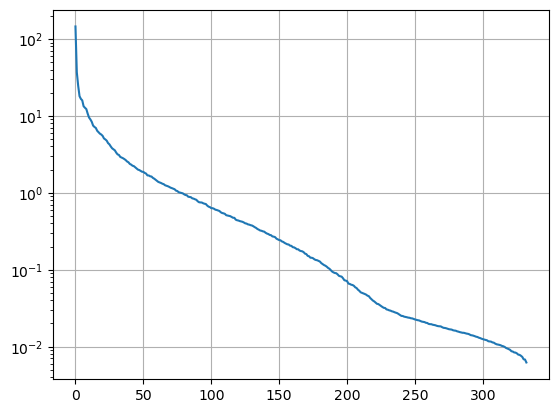

In [8]:
plt.semilogy(s)
plt.grid()

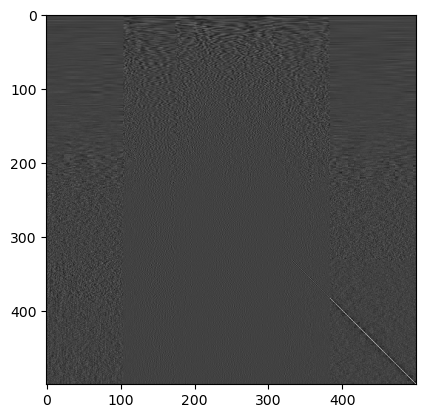

In [13]:
plt.imshow(V, cmap="gray")

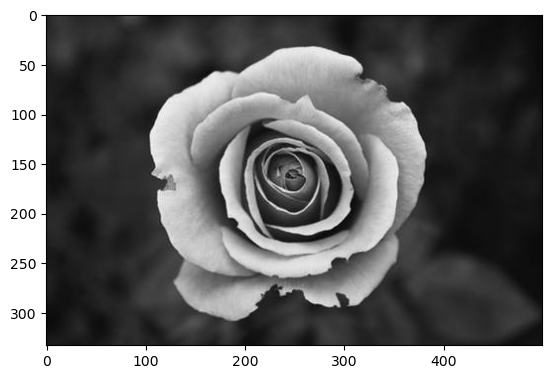

In [32]:
p = 300
Ap = U[:, :p] @ np.diag(s[:p]) @ V[:p, :]
plt.imshow(Ap, cmap="gray");

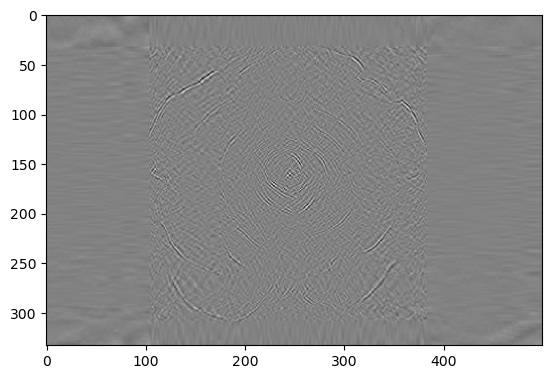

In [38]:
plt.imshow(grey-Ap, cmap="gray");

### Resolution in terms of SVD
The model resolution
$$ {\bf G}^\dagger {\bf G} = {\bf V}_p {\bf \Sigma}^{-1}_p{\bf U}^T_p {\bf U}_p{\bf \Sigma}_p{\bf V}_p^T = {\bf V}_p {\bf V}_p^T $$
depends only on the model eigenvectors!

And the data resolution
$$ {\bf G} {\bf G}^\dagger = {\bf U}_p{\bf \Sigma}_p{\bf V}_p^T {\bf V}_p {\bf \Sigma}^{-1}_p{\bf U}^T_p = {\bf U}_p {\bf U}_p^T $$
depends only on the data eigenvectors!

Let us look at the eigenvectors of the overdetermined matrix problem.

In [41]:
G = np.array([[1, -1], [2, -1], [1, 1]]);
d = np.array([[-1], [0], [2.5]]);
s = np.linalg.svd(G)

In [52]:
U, s, V = np.linalg.svd(G);

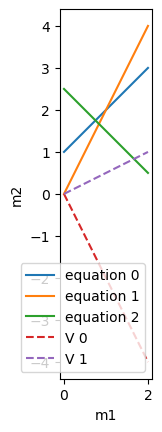

In [ ]:
xx = np.array([0, 2])
fig, ax = plt.subplots()
for i in range(3):
    yy = (d[i] - G[i, 0] * xx) / G[i, 1]
    ax.plot(xx, yy, label=f"equation {i}")

ax.set_xlabel("m1")
ax.set_ylabel("m2")
for i in range(2):
    yy = (V[i, 0] * xx) / V[i,1]
    ax.plot(xx, yy, "--", label=f"V {i}")

ax.legend()
ax.set_aspect("equal")

In [33]:
64200*1.19

76398.0

### Eigenvectors of the regression problem

2-element Vector{Float64}:
 10.913048571640049
  2.5407421894055084

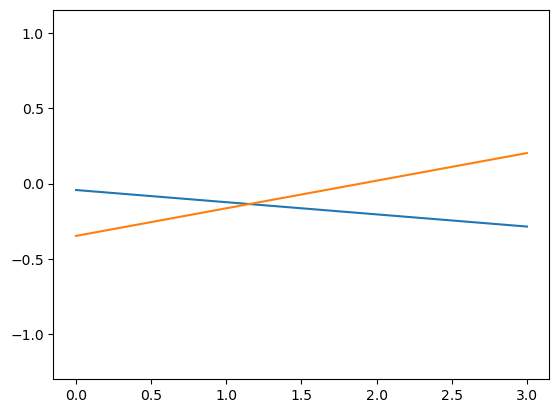

(-0.15000000000000002, 3.15, -0.37563114475083725, 0.23066762480711733)

In [ ]:
x = 0:0.1:3.0
G = ones(length(x), 2)
G[:, 1] = x[:]  # column vector
s = svd(G)
display(s.S)
plot(x, s.U[:, 1])
plot(x, s.U[:, 2])
axis("equal")

In [ ]:
A = [1 1 0 0;1 1.1 0 0;0 0 1 0.5;0 0 0.5 1]
s = svd(A)
print(round.(s.S, digits=2))

[2.05, 1.5, 0.5, 0.05]

In [ ]:
AI = pinv(A, rtol=0.1)
m = [10;11;12;13]
d = A*m
print(round.(d, digits=2))

[21.0, 22.1, 18.5, 19.0]

In [ ]:
error = 0.2
for i in 1:5
    dnoise = d + randn(4) * error
    mest = AI * dnoise
    print(round.(mest, digits=2))
    print("\n")
end


[10.1, 10.62, 12.21, 12.93]
[10.23, 10.75, 12.35, 12.84]
[10.21, 10.73, 12.51, 12.61]
[10.31, 10.84, 11.95, 12.9]
[10.25, 10.78, 11.97, 12.98]
